In [1]:
from pathlib import Path
import argparse
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

from model import NetworkBinary

# =========================
# 1) Manual configuration
# =========================
dataset_name = "3_countries"
x_path = Path("../data") / dataset_name / "X_eval.npy"
model_path = Path("../model") / dataset_name / "model.pth"

# Plot output location
plot_dir = Path("../results") / dataset_name / "shap"
plot_name = "shap_summary_class1.png"
plot_dir.mkdir(parents=True, exist_ok=True)
plot_path = plot_dir / plot_name

# Hand-set model hyperparameters (must match training checkpoint)
FILTER_NUM = [64, 64]
WINDOW_SIZE = [8, 8]
STRIDES = [4, 4]
FORWARD_SIZE = 12
DROPOUT_RATE = 0.5

# SHAP runtime controls
BG_SIZE = 100
EXPLAIN_SIZE = 50

# =========================
# 2) Load X from NumPy file
# =========================
X = np.load(x_path).astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Model expects [batch, channels=1, features]
X_tensor = torch.from_numpy(X).unsqueeze(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================================
# 3) Build model with manual parameters
# ========================================
args = argparse.Namespace(
    filter_num=FILTER_NUM,
    window_size=WINDOW_SIZE,
    strides=STRIDES,
    forward_size=FORWARD_SIZE,
    dropout_rate=DROPOUT_RATE
)

num_features = X.shape[1]
model = NetworkBinary(args, num_features).to(device)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# ====================
# 4) Run SHAP explain
# ====================
bg_size = min(BG_SIZE, len(X_tensor))
explain_size = min(EXPLAIN_SIZE, len(X_tensor))
background = X_tensor[:bg_size].to(device)
to_explain = X_tensor[:explain_size].to(device)

explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(to_explain)

# For binary classifier, keep positive-class explanation
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_class1 = shap_values[1]
elif isinstance(shap_values, list):
    shap_class1 = shap_values[0]
else:
    shap_class1 = shap_values

# Convert shapes from [N, 1, F] to [N, F] for plotting
X_plot = to_explain.detach().cpu().numpy().squeeze(1)
if shap_class1.ndim == 3 and shap_class1.shape[1] == 1:
    shap_class1 = shap_class1.squeeze(1)

# =====================
# 5) Plot and save PNG
# =====================
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_class1, X_plot, show=False)
plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Loaded X shape: {X.shape}")
print(f"Background size: {bg_size} | Explained samples: {explain_size}")
print(f"Saved SHAP plot to: {plot_path.resolve()}")

Initializing convolutional layers with Xavier Uniform...
Initializing linear layers with Truncated Normal...


RuntimeError: Error(s) in loading state_dict for NetworkBinary:
	size mismatch for fc1.weight: copying a param with shape torch.Size([32, 704]) from checkpoint, the shape in current model is torch.Size([12, 1024]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for bn3.weight: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for bn3.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for bn3.running_mean: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for bn3.running_var: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for fc_out.weight: copying a param with shape torch.Size([2, 32

Loaded feature IDs from: ..\data\Croa_Hung_feature_ids.txt
Saved feature order: ..\data\Croatia_Hung\feature_order.npy
Saved clustered X:   ..\data\Croatia_Hung\X_clustered.npy  shape=(7, 156)
Saved clustered C:   ..\data\Croatia_Hung\c_clustered.npy  shape=(156, 156)
Saved text mapping:  ..\data\Croatia_Hung\feature_order_mapping.txt

First 10 clustered features (new_pos -> old_idx):
0 -> 2 (74ae5d404e2cb52f759ca157ef6f6936e98ae942)
1 -> 1 (bf306d3c65f3410a2ed0845bd467e97442e6b197)
2 -> 0 (3c60585944b45c6f45aebfb489bf3ab7b96321d8)
3 -> 3 (f7986644df1b54220d6b859584cd072c36e4ade2)
4 -> 4 (45c955a9509fee154c52237e3ed025e483b0d04a)
5 -> 42 (0f33d73fbbfe99ec5b205a4adeeef47dd88cc222)
6 -> 41 (c184fa158f3b74f89412fcc500ead6af5bff5640)
7 -> 39 (e642a467a195b454263cd1ca4761d691a6bd1d75)
8 -> 40 (0628135b28b1f99e3befa2ad8416f7925b5c89fd)
9 -> 38 (d3bc3c089fbad2c78179263f28b1cf6d31c7cd74)


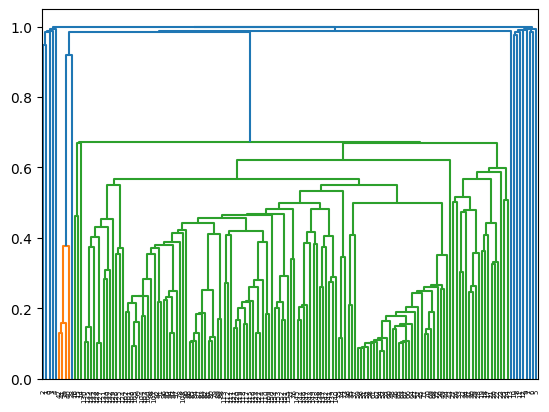

In [3]:
from pathlib import Path
import importlib
import numpy as np
import HAC

# Ensure latest HAC.py edits are used in this kernel session
importlib.reload(HAC)

# Dataset folder under ../data (e.g., 3_countries, China_Hung, Croatia_Hung)
dataset_name = "Croatia_Hung"
data_dir = Path("../data") / dataset_name

x_file = data_dir / "X_eval.npy"   # change to X_train.npy or X.npy if needed
c_file = data_dir / "c.npy"

# Output files
order_file = data_dir / "feature_order.npy"
x_clustered_file = data_dir / "X_clustered.npy"
c_clustered_file = data_dir / "c_clustered.npy"
mapping_txt_file = data_dir / "feature_order_mapping.txt"

# Load arrays
X = np.load(x_file)
C = np.load(c_file)

if X.shape[1] != C.shape[0] or C.shape[0] != C.shape[1]:
    raise ValueError(
        f"Shape mismatch: X={X.shape}, C={C.shape}. Expected X[:, n_features] and C[n_features, n_features]."
    )

# Hierarchical clustering order from correlation matrix C
feature_order = np.array(HAC.hac(C), dtype=np.int64)

# Reorder X columns and both axes of C using the same feature order
X_clustered = X[:, feature_order]
C_clustered = C[np.ix_(feature_order, feature_order)]

# Save clustered arrays
np.save(order_file, feature_order)
np.save(x_clustered_file, X_clustered)
np.save(c_clustered_file, C_clustered)

# Auto-detect feature IDs file from ../data and match by feature count
n_features = X.shape[1]
feature_ids = None
feature_id_files = sorted(Path("../data").glob("*_feature_ids.txt"))

for candidate in feature_id_files:
    with open(candidate, "r", encoding="utf-8") as f:
        raw = [line.strip() for line in f if line.strip()]

    # Remove optional header rows such as #OTUID
    cleaned = [line for line in raw if not line.startswith("#")]

    if len(cleaned) == n_features:
        feature_ids = cleaned
        print(f"Loaded feature IDs from: {candidate}")
        break

if feature_ids is None:
    print(
        f"No matching *_feature_ids.txt found for {n_features} features. "
        "Using fallback names feature_<original_index>."
    )

# Build human-readable mapping: clustered_position -> original_index (+ name)
lines = ["clustered_position\toriginal_index\tfeature_name"]
for new_pos, old_idx in enumerate(feature_order):
    if feature_ids is not None and old_idx < len(feature_ids):
        name = feature_ids[old_idx]
    else:
        name = f"feature_{old_idx}"
    lines.append(f"{new_pos}\t{old_idx}\t{name}")

with open(mapping_txt_file, "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print(f"Saved feature order: {order_file}")
print(f"Saved clustered X:   {x_clustered_file}  shape={X_clustered.shape}")
print(f"Saved clustered C:   {c_clustered_file}  shape={C_clustered.shape}")
print(f"Saved text mapping:  {mapping_txt_file}")

print("\nFirst 10 clustered features (new_pos -> old_idx):")
for row in lines[1:11]:
    cols = row.split("\t")
    print(f"{cols[0]} -> {cols[1]} ({cols[2]})")

In [11]:
from pathlib import Path
import zipfile
import pandas as pd

# -----------------------------
# Configure paths
# -----------------------------
dataset_name = "3_countries"
mapping_file = Path("../data") / dataset_name / "feature_order_mapping.txt"
output_file = Path("../data") / dataset_name / "feature_order_with_taxonomy.tsv"

# Candidate taxonomy files (QZA or TSV)
# Include both underscore and camel-case folder naming variants.
taxonomy_candidates = [
    Path("../data") / dataset_name / "taxonomy.qza",                    # ../data/3_countries/taxonomy.qza
    Path("../data") / "3Countries" / "taxonomy.qza",                  # ../data/3Countries/taxonomy.qza
    Path("../data") / dataset_name / "taxonomy_export" / "taxonomy.tsv",
    Path("../data") / "3Countries" / "taxonomy_export" / "taxonomy.tsv",
    Path("../data") / "taxonomy.qza",                                  # fallback; may belong to another dataset
]

if not mapping_file.exists():
    raise FileNotFoundError(f"Mapping file not found: {mapping_file}")

# -----------------------------
# Load mapping table
# -----------------------------
mapping_df = pd.read_csv(mapping_file, sep="\t")
required_cols = {"clustered_position", "original_index", "feature_name"}
missing = required_cols.difference(mapping_df.columns)
if missing:
    raise ValueError(f"Mapping file is missing required columns: {sorted(missing)}")

mapping_ids = set(mapping_df["feature_name"].astype(str))
expected_n = len(mapping_ids)


def load_taxonomy_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".qza":
        with zipfile.ZipFile(path, "r") as z:
            taxonomy_members = [n for n in z.namelist() if n.endswith("/data/taxonomy.tsv")]
            if not taxonomy_members:
                raise ValueError(f"No /data/taxonomy.tsv found inside {path}")
            with z.open(taxonomy_members[0], "r") as fh:
                return pd.read_csv(fh, sep="\t", comment="#")
    return pd.read_csv(path, sep="\t", comment="#")


def normalize_taxonomy_columns(df: pd.DataFrame) -> pd.DataFrame:
    norm = {c.lower().strip(): c for c in df.columns}
    fid_col = norm.get("feature id") or norm.get("feature-id") or norm.get("feature_id")
    taxon_col = norm.get("taxon")
    conf_col = norm.get("confidence")

    if fid_col is None or taxon_col is None:
        raise ValueError(f"Could not detect taxonomy columns. Found: {list(df.columns)}")

    keep_cols = [fid_col, taxon_col] + ([conf_col] if conf_col is not None else [])
    out = df[keep_cols].copy()
    rename_map = {fid_col: "feature_name", taxon_col: "taxonomy"}
    if conf_col is not None:
        rename_map[conf_col] = "confidence"
    return out.rename(columns=rename_map)


# -----------------------------
# Pick best taxonomy candidate by ID overlap
# -----------------------------
best_path = None
best_tax = None
best_overlap = -1.0
scan_report = []

for cand in taxonomy_candidates:
    if not cand.exists():
        continue
    try:
        tax_df = normalize_taxonomy_columns(load_taxonomy_table(cand))
        tax_ids = set(tax_df["feature_name"].astype(str))
        overlap = len(mapping_ids & tax_ids) / max(len(mapping_ids), 1)
        scan_report.append((str(cand), overlap, len(tax_ids)))
        if overlap > best_overlap:
            best_overlap = overlap
            best_path = cand
            best_tax = tax_df
    except Exception as e:
        scan_report.append((f"{cand} (error: {e})", 0.0, 0))

if best_tax is None:
    raise FileNotFoundError(
        "No taxonomy file found. Put taxonomy.qza (or taxonomy.tsv) in one of: \n"
        "- ../data/3_countries/\n"
        "- ../data/3Countries/\n"
        "- ../data/3_countries/taxonomy_export/\n"
        "- ../data/3Countries/taxonomy_export/"
    )

# Require strong overlap to prevent accidentally using another dataset's taxonomy
if best_overlap < 0.80:
    lines = [f"{p} | overlap={ov:.3f} | taxonomy_ids={n}" for p, ov, n in scan_report]
    raise ValueError(
        "No matching 3_countries taxonomy found (best overlap < 0.80).\n"
        f"Expected about {expected_n} taxonomy IDs from mapping.\n"
        f"Best candidate: {best_path} with overlap {best_overlap:.3f}.\n"
        "Candidates scanned:\n- " + "\n- ".join(lines) + "\n\n"
        "This usually means the taxonomy artifact belongs to a different dataset. "
        "Generate taxonomy from final_3_countries_seqs.qza and retry."
    )

print(f"Using taxonomy file: {best_path}")
print(f"Feature-ID overlap with mapping: {best_overlap:.3f}")

# -----------------------------
# Merge and save
# -----------------------------
out_df = mapping_df.merge(best_tax, on="feature_name", how="left")
out_df = out_df.sort_values("clustered_position", kind="stable")
out_df.to_csv(output_file, sep="\t", index=False)

matched = out_df["taxonomy"].notna().sum()
print(f"Saved aligned table: {output_file}")
print(f"Matched taxonomy rows: {matched}/{len(out_df)}")
print(out_df.head(10).to_string(index=False))

Using taxonomy file: ..\data\3_countries\taxonomy.qza
Feature-ID overlap with mapping: 0.996
Saved aligned table: ..\data\3_countries\feature_order_with_taxonomy.tsv
Matched taxonomy rows: 270/271
 clustered_position  original_index                             feature_name                                                                                                                                      taxonomy  confidence
                  0              19 020a4147fdda0810264634c477c464877f797e04                            d__Bacteria;p__Firmicutes;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella;s__    1.000000
                  1              18 207cc82ff40d87754104a4b4ecc14f86c90c2340                                 d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pseudomonadales;f__Moraxellaceae;g__Acinetobacter;s__    0.999952
                  2              17 73251a92727c8aab29d42db10336185211501958                                 d